# The Magnificent Jump

สุรพัศ หอมชุ่ม · Math Nerd

[ต้นฉบับ](https://qc-variance-gamma-model.nutdnuy.chatgpt.site/) · จัดเป็น 3 ตอน โดยคงถ้อยคำและสมการต้นฉบับ

ส่วน Viz เพิ่มเติมใช้ข้อมูลสมมติ แสดงผลไว้แล้ว และรันซ้ำได้ด้วย Python 3, NumPy และ Matplotlib ใช้ Run All ตามลำดับเพื่อสร้างกราฟใหม่ การจัดเล่มนี้ไม่ได้ตรวจแก้เนื้อหาต้นฉบับ

[ตอนที่ 1](#part-1) · [ตอนที่ 2](#part-2) · [ตอนที่ 3](#part-3)

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

plt.rcParams.update({
    "font.family": "Roboto" if any(f.name == "Roboto" for f in font_manager.fontManager.ttflist) else "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": "#222222", "text.color": "#222222",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "svg.fonttype": "path", "svg.hashsalt": "magnificent-jump",
})
PURPLE, TEAL, GRAY = "#6200EE", "#007D73", "#666666"

def finish(axes):
    for ax in np.atleast_1d(axes):
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.7)
        ax.set_axisbelow(True)
        ax.legend(frameon=False, fontsize=10)
    plt.show()


<a id="part-1"></a>

## ตอนที่ 1 · Intro

<div class="vg-source-block" data-source-block="0"><header class="post-header"><span>RESEARCH NOTE</span><h2>Intro</h2></header></div>

<div class="vg-source-block" data-source-block="1"><blockquote><p>“แม้นข้าพเจ้าจะสามารถคํานวณการเคลื่อนที่ของดวงดาวแสนอัสจรร์บนเวิ้งฟ้าได้อย่างแม่นยํา...แต่ข้าพเจ้าไม่สามารถคํานวณความบ้าคลั่งของผองชนได้เลย”</p><cite>เซอร์ ไอแซค นิวตัน กล่าวถึง วิกฤติฟองสบู่หุ้นบริษัท South Sea ค.ศ. 1720</cite></blockquote></div>

<div class="vg-source-block" data-source-block="2"><p>แม้แต่นักคิดผู้ชาญฉลาดที่สุดคนนึงในประวัติศาสตร์มนุษยชาติก็ยอมแพ้ให้กับความบ้าคลั่งของตลาดหุ้น แต่ผมเข้าใจท่านเซอร์นะ ณ ตอนนั้นยังไม่มีการศึกษาพฤติกรรมของตลาดหุ้นอย่างจริงจัง จนกระทั่งเกือบสองร้อยปีต่อมา Quant คนแรกในถือกําเนิดขึ้นบนโลก เขาเป็นนักคณิตศาสตร์ชาวฝรั่งเศษที่ชื่อว่า ‘ลุยส์ บาร์เชลิเยร์ (Louis Bachelier)’ บาร์เชลิเยร์ได้เสนอแนวคิดที่ว่า ‘ราคาของหุ้นในตลาดเปลี่ยนแปลงแบบสุ่ม’ มันสุ่มไปเรื่อยไม่แน่นอน เมื่อราคาของหุ้นเปลี่ยนแปลงแบบสุ่มคณิตศาสตร์ที่จะเข้ามาอธิบายมันได้คือพวกทฤษฏีความน่าจะเป็น (Probability Theory) และ แคลคูลัสเกี่ยวกับความไม่แน่นอน (Stochastic Calculus) ซึ่งพัฒนามาจากทฤษฎีความน่าจะเป็นอีกที</p></div>

<div class="vg-source-block" data-source-block="3"><p>สิ่งที่บาร์เชลิเยร์ตั้งคําถามต่อมาคือ ‘ราคาของหุ้นเนี่ยเปลี่นแปลงตามการแจกแจงความน่าจะเป็น (Probability Distribution) ชนิดไหน ?’ ซึ่งบาร์เชลิเยร์เสนอว่ามันเปลี่ยนตามการแจกแจงปกติ (Normal Distribution ที่เราได้เรียนครั้งแรกในวิชาสถิติตอนม.ปลายนั่นแหล่ะ) ซึ่ง model ที่เขาเสนอใช้ Brownian Motion (เป็น model ทางคณิตศาสตร์ที่เปลี่ยนแปลงแบบ Normal Distribution ตามเวลา) มาจําลองการเปลี่ยนแปลงของราคาหุ้น</p></div>

<div class="vg-source-block" data-source-block="4"><p>ซึ่งหลังจากการเสนอของ บาร์เชลิเยร์ ก็มีนักคณิตศาสตร์ (หลังจากนี้ผมจะเรียกว่า Quant ละกัน เพราะ Quants สําหรับผมคือนักคณิตศาสตร์/นักฟิสิกส์ ที่ศึกษาพฤติกรรมของตลาด) พัฒนา model ต่อจากเขาโดยใช้ Brownian Motion เป็นส่วนประกอบ ซึ่ง model ที่โด่งดังมากคือ Geometric Brownian Motion ที่ใช้ในสมการเปลี่ยนโลก Black-Schole and Merton Equation (สมการนี้ได้ฉายาว่า ‘สมการล้านล้านดอลลาร์’ the trillion dollars equation) สมการ Black-Schole นี้ใช้ในการตั้งราคาตราสารอนุพันธ์ประเภท Option ซึ่งผมจะอ้างอิงในหัวข้อด้านล่างแต่ตอนนี้ช่างมันก่อน</p></div>

<div class="vg-source-block" data-source-block="5"><p>กลับมาที่ Brownian Motion และ พฤติกรรมของตลาด ต่อมาพวก Quants เริ่มเห็นแล้วว่า ‘ราคาหุ้นในตลาดไม่ได้เปลี่ยนแปลงตาม Normal Distribution และ Brownian Motion/Geometric Brownian Motion ไม่เพียงพอในการสร้าง model จําลองราคาหุ้น’ ทําไงล่ะที่นี้? แต่ก่อนที่จะไปหาทางแก้เราไปดูหลักฐานกันก่อนว่าแล้วราคาหุ้นในตลาดเปลี่ยนแปลงยังไงกันแน่</p></div>

<div class="vg-source-block" data-source-block="6"><p>จากข้อมูลเก่า เมื่อพวก Quants นําอัตราผลตอบแทน (rate of return หรืออาจจะเป็น log-return) มาพล็อตกราฟ พบว่ากราฟของผลตอบแทนมีจุดสูงสุด (sharp peak) ที่สูงกว่า Normal Distribution ไปมาก ไม่เพียงเท่านั้นตรงหาง(tail) ของกราฟยังมีลักษณะตํ่ากว่าตัว Normal Distribution (เราเรียก distribution ลักษณะนี้ว่า heavy-tailed distribution)</p></div>

<div class="vg-source-block" data-source-block="7"><p>จิตนาการภาพง่ายๆ ให้นึกว่าตัวกราฟ Normal Distribution เป็นเหมือนเยลลี่เด้งดึ๋ง จากนั้นเราเอามือมากดหางของตัวกราฟ Normal Distribution ไว้ไม่ข้างใดก็ข้างหนึ่งหรืออาจจะทั้งสองข้างทําให้หางบุ๋มลง (เกิดเป็น heavy-tailed) พอไอ้เยลลี่ Normal Distribution โดนกดก็ไม่พอใจเลยขัดขืนบวกกับมันพยายามดิ้นให้หลุดจากการโดนกดเลยเอาหัวหม่งขึ้นบนหรืออาจจะเบ้ซ้ายหรือเบ้ขวา ในทิศตรงข้ามกับที่เรากดหางของมัน (เกิดเป็น sharp peak)</p></div>

<div class="vg-source-block" data-source-block="8"><p>โดยในทางคณิตศาสตร์เรามีตัววัดระดับความ peak เรียกว่า ‘Kurtosis’ และวัดระดับความเบ้เรียกว่า ‘Skewness’ (Skewness เกิดขึ้นตอนเรากดหางไอ้เยลลี่ Normal Distribution แค่ข้างเดียว เกิดเป็นกราฟที่ทั้งเอียงและทั้งหัวโด่ แต่ถ้าเรากดมันทั้งสองข้างก็จะไม่มี Skewness มีแต่ Kurtosis เกิดเป็นกราฟสมมาตรแต่ยังหัวโด่) ***คําว่าหัวโด่หมายถึงตัว Kurtosis ของการฟสูงกว่าตัว Kurtosis ของ Normal Distribution</p></div>

<div class="vg-source-block" data-source-block="9"><p>เมื่อพวก Quants เห็นดังนั้นก็ตั้งคําถามต่อว่า “distribution พวกนี้มันเกิดจากอะไรหว่า?” พอหาคําตอบก็ค้นพบว่า distribution พวกนี้เกิดจาก</p></div>

<div class="vg-source-block" data-source-block="10"><ol class="numbered"><li>เหตุการณ์ที่ตลาด shock ผู้คนเกิดอาการตื่นตระหนกรุมกันเทขายหุ้นทําให้ราคาดิ่ง หรือรุมกันซื้อหุ้นทําให้ราคาพุ่งแรง ในกรณีแรกในทางคณิตศาสตร์จะเรียกว่า “Negative Big Jump” ส่วนในกรณีหลังจะเรียกว่า “Positive Big Jump”</li><li>การที่กิจกรรมการ trade หุ้นของผู้คนไม่ได้เกิดตลอดเวลาทําให้ตัวราคาหุ้นเปลี่ยนแบบ “ไม่ต่อเนื่อง (discontinuous)” ทําให้เกิดเป็น ‘Small Jump (รวมทั้ง negative และ positive)’ ขึ้น ***</li></ol></div>

<div class="vg-source-block" data-source-block="11"><p>ซึ่งตัว model ที่มี Brownian Motion เป็นส่วนประกอบจะมีสมมติฐานคือ กิจกรรมการ trade หุ้นในตลาดเกิดอย่างต่อเนื่อง (continuous) นี่จึงเป็นเหตุผลสําคัญว่าทําไม model ที่มีเพียง Brownian Motion เป็นส่วนประกอบจึงไม่เพียงพอ เมื่อเป็นดังนี้เราจึงต้องสร้าง models ขึ้นมาใหม่ ‘แล้วจะสร้าง models ใหม่ยังไงห้ะ?’ ต้องติดตามโพสต์ต่อไป</p></div>

<div class="vg-source-block" data-source-block="12"><aside class="note">*** หมายเหตุ ความจริงเหตุการณ์ที่ตลาด shock ในข้อ 1) ก็คือการที่ราคาหุ้นเกิดการเปลี่ยนแปลงแบบไม่ต่อเนื่องในข้อ 2) นั่นแหล่ะ เพียงแต่ผมต้องการให้ผู้อ่านเห็นภาพระหว่าง big jump และ small jump ซึ่ง quants บางคนจะเรียกรวมๆว่า jump ไปเลย</aside></div>

### Viz เพิ่มเติม

Viz เพิ่มเติม · ตัวอย่างสมมติ: เปรียบเทียบ Normal กับ symmetric Variance Gamma ที่มีค่าเฉลี่ย 0 และ variance 0.04 เท่ากัน กำหนด T = 1, θ = 0, σ = 0.2, ν = 1, μ = 1 กรณีนี้ VG เป็น Laplace distribution กราฟขวาใช้แกนความหนาแน่นแบบ log; ไม่ใช่ข้อมูลตลาด

[แบบจำลองอ้างอิงสำหรับ Viz: Madan, Carr & Chang (1998)](https://engineering.nyu.edu/sites/default/files/2018-09/CarrEuropeanFinReview1998.pdf)

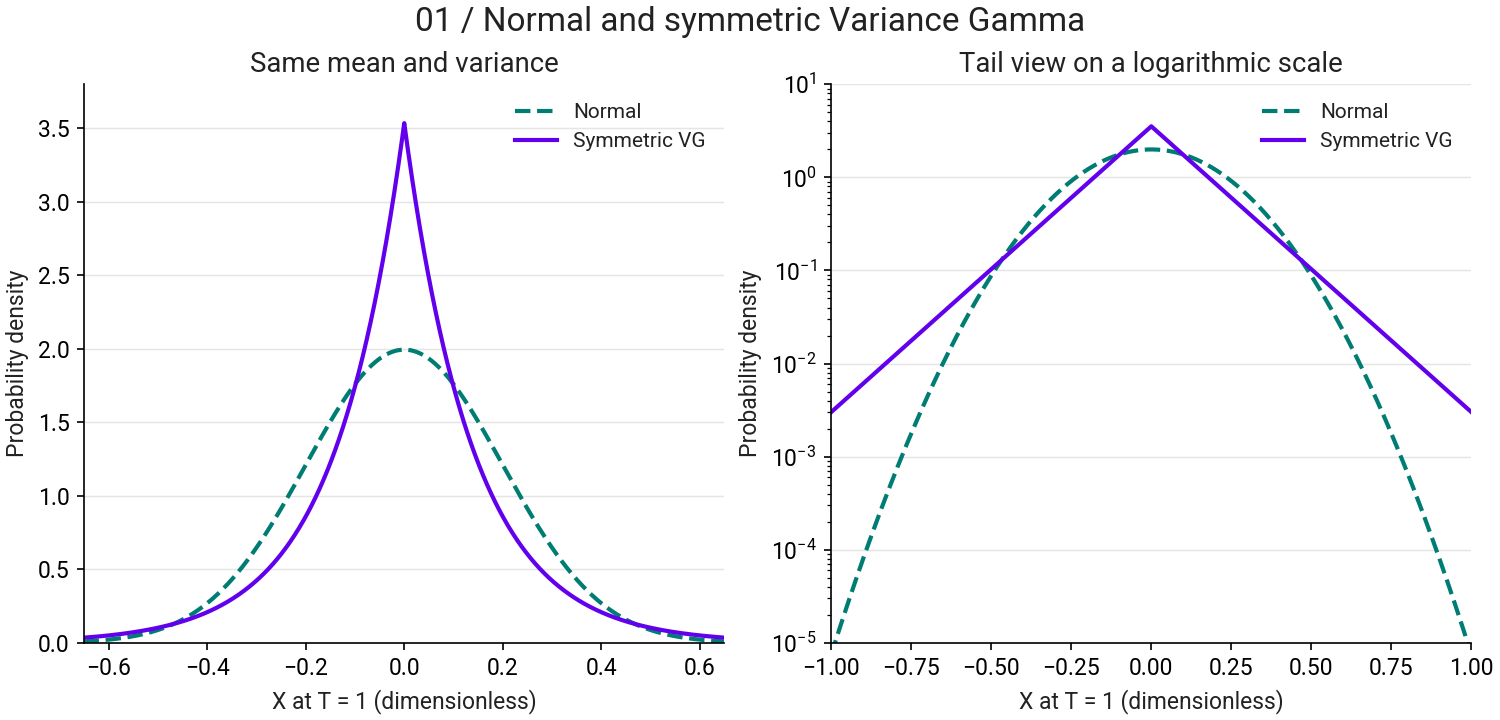

In [2]:
# Hypothetical distributions, not empirical returns.
# With T=nu=1 and theta=0, VG is Laplace with scale sigma/sqrt(2).
sigma, T, nu = 0.2, 1.0, 1.0
x = np.linspace(-1, 1, 2001)
b = sigma / math.sqrt(2)
normal = np.exp(-0.5*(x/sigma)**2) / (sigma*math.sqrt(2*math.pi))
vg = np.exp(-np.abs(x)/b) / (2*b)
assert math.isclose(2*b*b, sigma*sigma)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), layout="constrained")
for ax in axes:
    ax.plot(x, normal, color=TEAL, linestyle="--", linewidth=2, label="Normal")
    ax.plot(x, vg, color=PURPLE, linewidth=2, label="Symmetric VG")
    ax.set_xlabel("X at T = 1 (dimensionless)")
    ax.set_ylabel("Probability density")
axes[0].set_title("Same mean and variance")
axes[0].set_xlim(-0.65, 0.65)
axes[0].set_ylim(0, 3.8)
axes[1].set_title("Tail view on a logarithmic scale")
axes[1].set_yscale("log")
axes[1].set_ylim(0.00001, 10)
axes[1].set_xlim(-1, 1)
fig.suptitle("01 / Normal and symmetric Variance Gamma", fontsize=16)
finish(axes)


<a id="part-2"></a>

## ตอนที่ 2 · นาฬิกาสุ่ม (random clock)

<div class="vg-source-block" data-source-block="13"><p>การจะสร้าง jump model มีวิธีการหลักๆอยู่ 3 วิธี แต่ในที่นี้เพื่อไม่ให้ NERD เกินไปและให้สอดคล้องกับตัวอย่างในโพสต์ถัดไป ผมจะนําเสนอเพียงวิธีเดียวนั่นคือวิธีที่ชื่อว่า “ยัดนาฬิกาสุ่ม (random clock) เข้าไปใน Brownian Motion หรือ วิธี Subordination of Brownian Motion” แต่ก่อนไปสร้าง model เราต้องทําความรู้จัก ‘นาฬิกาสุ่ม (random clock)’ กันก่อน</p></div>

<div class="vg-source-block" data-source-block="14"><h2 id="random-clock">นาฬิกาสุ่ม (random clock)</h2></div>

<div class="vg-source-block" data-source-block="15"><p>เหมือนที่ผมกล่าวในโพสต์ที่แล้วว่าตลาดหุ้นเปลี่ยนแปลงแบบไม่ต่อเนื่อง (discontinuous) พวก Quants จึงสร้างเวลาขึ้นมาใหม่เพื่อล้อกับตัวความไม่ต่อเนื่องนี้ สมมติให้เวลาที่ถูกสร้างขึ้นนี้คือ τ (ภาษากรีก อ่านว่า ‘ทัลก์ (tau)’ หรือ ‘เทา’ นั่นแหล่ะง่ายๆ)</p></div>

<div class="vg-source-block" data-source-block="16"><p>ซึ่งตัว τ นี่แหล่ะคือที่เราเรียกว่า นาฬิกาสุ่ม (random clock) โดยปัจจัยที่ส่งผลต่อ τ คือ เหตุการณ์ต่างๆ (random events)/ข้อมูล (information) และ ‘เวลา (t)’ ซึ่งต่อไปนี้เราจะแทน</p></div>

<div class="vg-source-block" data-source-block="17"><ul class="mapping"><li><span>เวลา (ธรรมดา)</span><b>t</b></li><li><span>เหตุการณ์ต่างๆ (random events) / ข้อมูล (information)</span><b>ω</b></li><li><span>เวลาสุ่ม / นาฬิกาสุ่ม</span><b>τ</b></li></ul></div>

<div class="vg-source-block" data-source-block="18"><p>โดย τ เป็นฟังก์ชันของ t และ ω หรือ τ(t,ω) นั่นเองและในบริบทนี้ τ คือเวลาที่ราคาหุ้นจะเปลี่ยน ซึ่งในเมื่อ τ นั้น ‘สุ่ม’ หมายความว่าเราต้องกําหนดด้วยว่า τ นั้นมีความแจกแจงความน่าจะเป็น (probability distribution) ประเภทอะไร เราจะพูดถึงหลักการในการกํานดตัว probability distribution ของ τ ในหัวข้อการสร้าง model แต่ก่อนที่จะไปสร้างตัว model เรามาทําความรู้จักคร่าวๆก่อนว่า ‘probability distribution’ กับ ‘probability process (หรือ stochastic process) ต่างกันอย่างไรเพื่อต่อไปจะได้ไม่สับสน</p></div>

<div class="vg-source-block" data-source-block="19"><h2>ความแตกต่างระหว่าง Probability Distribution และ Stochastic Process</h2></div>

<div class="vg-source-block" data-source-block="20"><p>ง่ายๆเลยคือตัว probability distribution เป็นฟังก์ชันของ ‘เหตุการณ์สุ่ม (random events) ω’ ส่วน stochastic process เป็นฟังก์ชันของ ‘เหตุการณ์สุ่ม (random events) ω และ เวลา t’ ถ้าเขียนในรูปฟังก์ชันจะได้ว่า</p></div>

<div class="vg-source-block" data-source-block="21"><div class="equation-pair"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><figcaption style="display:block;text-align:left;font-size:0.8em;margin-bottom:8px;">Probability Distribution</figcaption><div>f(ω)</div></figure><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><figcaption style="display:block;text-align:left;font-size:0.8em;margin-bottom:8px;">Stochastic Process</figcaption><div>f(t,ω)</div></figure></div></div>

<div class="vg-source-block" data-source-block="22"><p>ในทางคณิตสาสตร์ถ้าตัวแปรสุ่ม X ไม่ขึ้นกับเวลาเราจะเขียนว่า X(ω) หรือย่อว่า X เฉยๆอย่างที่คุ้นๆกันดี (เป็น probability distribution) แต่ถ้าตัวแปรสุ่ม X ขึ้นกับเวลา เราจะเขียนว่า X(t,ω) หรือย่อว่า X(t) (เป็น stochastic process)</p></div>

<div class="vg-source-block" data-source-block="23"><p>ยกตัวอย่าง Stochastic Process เช่น Brownian Motion เป็น normal distribution ที่มี parameters ขึ้นกับเวลา</p></div>

<div class="vg-source-block" data-source-block="24"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>B(t) ~ Normal Distribution(0, √t)</div></figure></div>

<div class="vg-source-block" data-source-block="25"><p>B(t) แทน Brownian Motion จะเห็นว่า B(t) เป็น Normal Distribution ที่มีค่าเฉลี่ย (mean) เป็นศูนย์ และ ค่า standard deviation เป็น √t (ค่า square root ของเวลา) ซึ่งจะเห็นชัดเจนว่าเมื่อเวลา t เปลี่ยน parameter ก็จะเปลี่ยนตาม (ในกรณีนี้คือ standard deviation)</p></div>

<div class="vg-source-block" data-source-block="26"><aside class="note">* Stochastic process X(t) อาจจะเป็นได้หลาย probability distributions ขึ้นอยู่กับเวลาที่เปลี่ยนแปลงไป แต่ในโพสต์นี้และโพสต์ถัดไปเราจะพูดถึงแค่ stochastic process ที่มี probability distribution ชนิดเดิมแม้เวลาจะเปลี่ยน (ชนิดของ probability distribution ไม่เปลี่ยน แต่ค่า parameters ที่ควบคุม probability distribution เปลี่ยนตามเวลาอยู่ดี)</aside></div>

<div class="vg-source-block" data-source-block="27"><p>มาถึงตรงนี้เราจะสังเกตุได้ว่าเจ้า ‘นาฬิกาสุ่ม τ(t,ω)’ นั้นเป็น Stochastic Process</p></div>

<div class="vg-source-block" data-source-block="28"><h2 id="build-model">สร้าง Model</h2></div>

<div class="vg-source-block" data-source-block="29"><p>Model ประเภทนี้เราจะเริ่มตั้งต้นว่าการเปลี่ยนแปลงของราคาหุ้น (หรือเป็นอัตราผลตอบแทน rate of return ก็ได้) เปลี่ยนตาม Brownian Motion เหมือนเดิม เพียงแต่เปลี่ยน ‘เวลา(t)’ ข้างในตัว Brownian Motion เป็น ‘เวลาสุ่ม(τ)’ แทน จาก B(t) เฉยๆกลายเป็น B(τ(t,ω)) โดย B(t) หมายถึง Brownian Motion มาถึงตอนนี้เราจะเห็นแล้วว่าจากที่</p></div>

<div class="vg-source-block" data-source-block="30"><div class="equation-flow"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>B(t) ~ Normal Distribution(0, √t)</div></figure><span>เป็น</span><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>B(τ(t,ω)) ~ ???</div></figure></div></div>

<div class="vg-source-block" data-source-block="31"><p>โดยตัว B(τ) (ต่อไปนี้ผมจะเขียน B(τ(t,ω)) หรืออาจจะเขียน B(τ) สลับไปมาแล้วแต่บริบท) จะมีหน้าตาเป็นแบบไหนนั้นขึ้นอยู่กับ τ นั่นเอง</p></div>

<div class="vg-source-block" data-source-block="32"><h2>Stochastic Process ของ τ</h2></div>

<div class="vg-source-block" data-source-block="33"><p>มีงานวิจัยมมากมาย นําเสนอ Stochastic Process ของเจ้านาฬิกาสุ่ม τ ซึ่งในที่นี้ผมจะนําเสนอผลงานของ Peter Carr, Dilip Madan และ Eric Chang ซึ่งเป็น Quants ที่ผมนับถือมากๆ (โดยเฉพาะ Peter Carr) ท่านเสนอ model ที่นาฬิกาสุ่ม τ เป็น Gamma Process หรือก็คือ Gamma Distribution ที่เปลี่ยนแปลงตามเวลา t โดยเจ้า Gamma distribution นี้ถูกกํากับด้วย parameters μ (อ่านว่า ‘มิว’ หรือ ‘mu’) และ ν (อ่านว่า ‘นู’ หรือ ‘nu’) โดย</p></div>

<div class="vg-source-block" data-source-block="34"><dl class="parameters"><div><dt>μ</dt><dd>คือ อัตราค่าเฉลี่ยต่อหนึ่งหน่วยเวลา หรือ mean rate</dd></div><div><dt>ν</dt><dd>คือ อัตราความแปรปรวนต่อหนึ่งหน่วยเวลา หรือ variance rate</dd></div></dl></div>

<div class="vg-source-block" data-source-block="35"><p>เมื่อนํามาเขียนในรูปของ Gamma Process จะได้ว่า</p></div>

<div class="vg-source-block" data-source-block="36"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>τ Gamma Distribution(μt, νt)</div></figure></div>

<div class="vg-source-block" data-source-block="37"><p>โดย parameters μ และ ν สองตัวนี้จะคอยควบคุมทั้งความเบ้ (skewness) และ ความ peak (kurtosis) ใน model ราคาหุ้นของเรานั่นเอง</p></div>

<div class="vg-source-block" data-source-block="38"><p>ในโพสต์ถัดไป ผมจะพูดถึงกระบวนการสุ่ม (stochastic process) ที่เกิดจากการยัดนาฬิกา gamma process นี้เข้าไปใน Brownian Motion และวิธีการตั้งราคาตัวอนุพันธ์ Options จาก process นี้</p></div>

<div class="vg-source-block" data-source-block="39"><aside class="note">***โพสต์ถัดไปจะ nerd มากๆ โพสต์ที่ผ่านๆมาผมพยายามเต็มที่ที่จะอธิบายเป็นภาษามนุษย์โลกอย่างสุดความสามารถ แต่โพสต์ถัดไปคงหลีกเลี่ยงความ nerd ไม่ได้จริงๆ อย่าเพิ่งยอมแพ้ครับ</aside></div>

### Viz เพิ่มเติม

Viz เพิ่มเติม · ตัวอย่างจำลอง Gamma clock หนึ่งเส้นทาง: μ = 1, ν = 0.25, T = 1 ปี แบ่ง 180 time steps, seed = 2026092002 ใช้ Gamma increments ที่มี shape = Δt/ν และ scale = ν ภาพแสดงค่าบนกริดเวลา ไม่ได้แสดงทุก jump ระหว่างจุดสังเกต

[แบบจำลองอ้างอิงสำหรับ Viz: Madan, Carr & Chang (1998)](https://engineering.nyu.edu/sites/default/files/2018-09/CarrEuropeanFinReview1998.pdf)

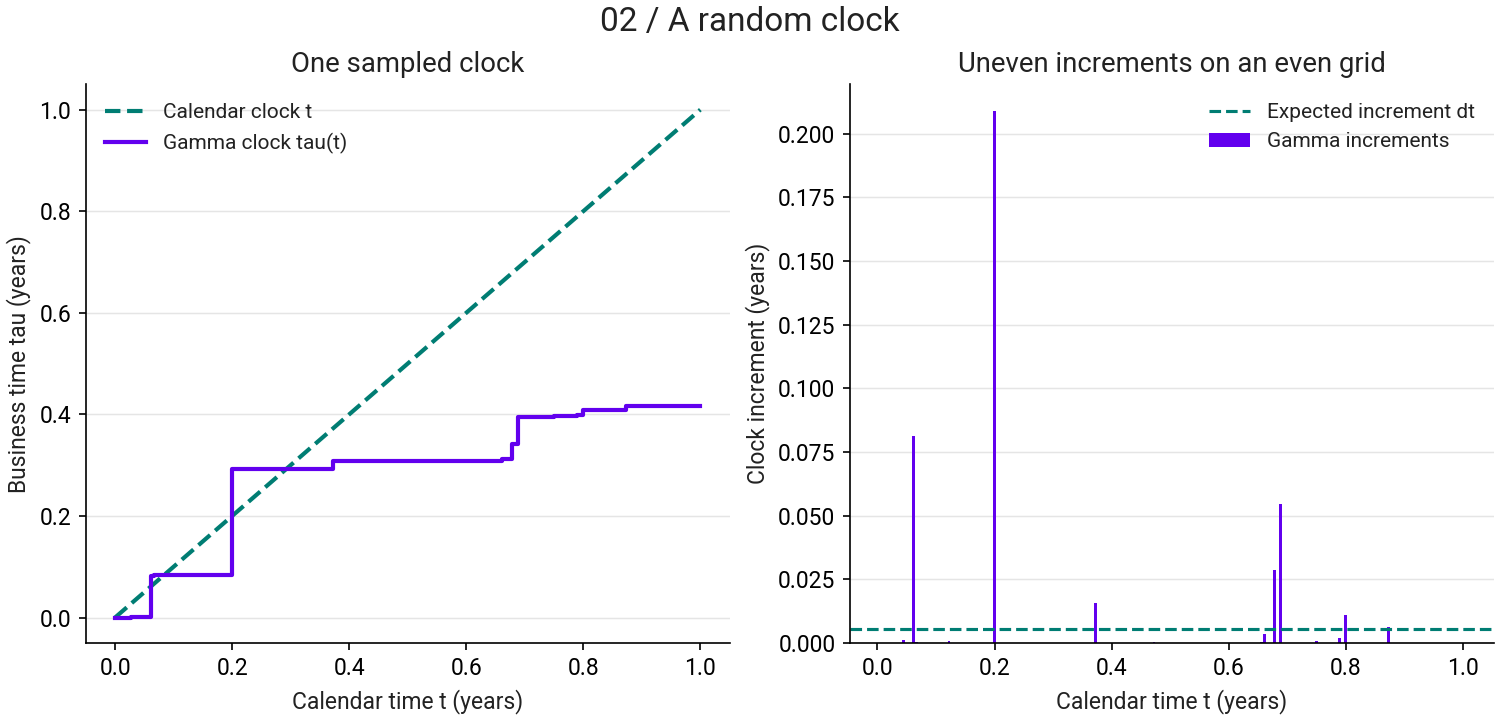

Hypothetical path: seed=2026092002; steps=180; nu=0.25; mu=1


In [3]:
# Gamma increments: shape=dt/nu, scale=nu, with mean rate mu=1.
# Lines are grid observations; the plot does not resolve infinitely many jumps.
seed, steps, T, nu = 2026092002, 180, 1.0, 0.25
rng = np.random.default_rng(seed)
dt = T / steps
t = np.linspace(0, T, steps+1)
increments = rng.gamma(shape=dt/nu, scale=nu, size=steps)
clock = np.r_[0, np.cumsum(increments)]
assert np.all(np.diff(clock) >= 0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), layout="constrained")
axes[0].plot(t, t, color=TEAL, linestyle="--", linewidth=2, label="Calendar clock t")
axes[0].step(t, clock, where="post", color=PURPLE, linewidth=2, label="Gamma clock tau(t)")
axes[0].set(xlabel="Calendar time t (years)", ylabel="Business time tau (years)", title="One sampled clock")
axes[1].bar(t[1:], increments, width=dt*0.9, color=PURPLE, label="Gamma increments")
axes[1].axhline(dt, color=TEAL, linestyle="--", label="Expected increment dt")
axes[1].set(xlabel="Calendar time t (years)", ylabel="Clock increment (years)", title="Uneven increments on an even grid")
fig.suptitle("02 / A random clock", fontsize=16)
finish(axes)
print(f"Hypothetical path: seed={seed}; steps={steps}; nu={nu}; mu=1")


<a id="part-3"></a>

## ตอนที่ 3 · Variance Gamma Process

<div class="vg-source-block" data-source-block="40"><p>เราเรียก stochastic process ที่เกิดจากการยัดนาฬิกาสุ่ม gamma เข้าไปใน Brownian Motion ว่า ‘Variance Gamma Process’ โดยสิ่งสําคัญที่สุดก่อนที่จะไปสร้าง model คือเราต้องทําความรู้จักเจ้า Variance Gamma Process กันก่อน</p></div>

<div class="vg-source-block" data-source-block="41"><h2 id="variance-gamma">Variance Gamma Process</h2></div>

<div class="vg-source-block" data-source-block="42"><p>เราทราบกันแล้วว่าตัว Variance Gamma Process นั้นเกิดจาก stochastic processes ทั้งหมดสองอันคือ</p></div>

<div class="vg-source-block" data-source-block="43"><ol class="numbered detailed"><li><strong>Gamma Process</strong> — เป็น process ของเจ้านาฬิกาสุ่ม τ โดยมีการแจกแจงแบบ gamma distribution ตามเวลา ซึ่ง gamma process มี probability density function (PDF) ดังนี้<figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>f<sub>t</sub>(τ) =<!-- --> <span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">(μ/ν)<sup>μ²t/ν</sup> · τ<sup>μ²t/ν − 1</sup> · exp(−μτ/ν)</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">Γ(μ²t/ν)</span></span>, τ &gt; 0</div></figure><p>โดย fₜ คือ PDF ของนาฬิกาสุ่ม τ</p></li><li><strong>Brownian Motion</strong> — เป็น process ดั้งเดิมที่เหล่า Quants ค้นพบว่าไม่เพียงพอในการทํา models โดยมีการแจกแจงแบบ normal distribution ตามเวลา ซึ่ง Brownian Motion โดยปกติจะมี PDF ดังนี้<figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>N<sub>t</sub>(x) =<!-- --> <span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">1</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">σ√(2πt)</span></span> <!-- -->exp<span class="paren"><span data-layout-only="true">(</span>−<span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">(x − θt)²</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">2σ²t</span></span><span data-layout-only="true">)</span></span>, x∈ℝ, t &gt; 0</div></figure><p>โดยที่ t เป็นเวลาปกติ ซึ่งพอเราปลี่ยน t เป็นเวลาสุ่ม τ จะได้ว่า</p><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>N<sub>τ</sub>(x) =<!-- --> <span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">1</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">σ√(2πτ)</span></span> <!-- -->exp<span class="paren"><span data-layout-only="true">(</span>−<span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">(x − θτ)²</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">2σ²τ</span></span><span data-layout-only="true">)</span></span>, x∈ℝ, τ &gt; 0</div></figure></li></ol></div>

<div class="vg-source-block" data-source-block="44"><p>ใน research paper ที่ผมอ้างอิง เขากําหนดให้ μ = 1 *** ใน PDF ของ Gamma Process และ Brownian Motion ที่นํามาใช้จะเพิ่มตัวแปร drift θ และ ความผันผวน (Volatility) σ เข้าไปด้วย</p></div>

<div class="vg-source-block" data-source-block="45"><p>จากนั้นเราจะได้ว่า PDF ของ Variance Gamma Process ซึ่งเกิดจากการยัดนาฬิกาสุ่ม τ เข้าไปใน Brownian Motion with drift ดังนี้</p></div>

<div class="vg-source-block" data-source-block="46"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>G<sub>t</sub>(x) = ∫<sub>0</sub><sup>∞</sup> <span class="paren"><span data-layout-only="true">(</span><span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">1</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">σ√(2πτ)</span></span> <!-- -->exp<span class="paren"><span data-layout-only="true">(</span>−<span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">(x − θτ)²</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">2σ²τ</span></span><span data-layout-only="true">)</span></span><span data-layout-only="true">)</span></span><span class="paren"><span data-layout-only="true">(</span><span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">(1/ν)<sup>t/ν</sup> · τ<sup>t/ν − 1</sup> · exp(−τ/ν)</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">Γ(t/ν)</span></span><span data-layout-only="true">)</span></span> <!-- -->dτ, x∈ℝ, τ &gt; 0</div></figure></div>

<div class="vg-source-block" data-source-block="47"><p>โดยที่ Gₜ(x) คือ PDF ของ Variance Gamma Process เราจะเห็นว่า Gₜ(x) เกิดจากการอินทิเกรตตัวแปร τ ตั้งแต่ 0 ถึง ∞ ดังนั้นฟังก์ชัน Gₜ(x) จะเป็นฟังก์ชันของตัวแปร t (เวลาที่ไม่สุ่ม) กับ x (ในที่นี้จะแทน log-return ดังที่จะกล่าวต่อไปในไม่กี่อึดใจ)</p></div>

<div class="vg-source-block" data-source-block="48"><p>ถึงตอนนี้หลายท่านอาจจะงงว่าอะไรคือตัวแปร drift θ กับตัวแปร Volatility σ ผมต้องท้าวความก่อนว่าปกติ Brownian Motion ที่มี mean=0 และ variance= t เราจะเรียกว่า Standard Brownian Motion จะเขียนอยู่ในรูป B(t) แต่ในกรณีที่เราจะปรับตัว mean ให้ไม่เท่ากับศูนย์เราจะบวกตัวแปร ‘drift’ เข้าไปเรียกว่า Brownian Motion with drift และเพิ่มเติมจาก drift เราจะคูณตัวแปร Volatility σ (ในที่นี้คือค่า standard deviation ของ Normal Distribution) เข้าไปใน Brownian Motion เพื่อสะท้อนความเป็นจริงมากที่สุด ซึ่งจะเขียนในรูป</p></div>

<div class="vg-source-block" data-source-block="49"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>θt + σB(t)</div></figure></div>

<div class="vg-source-block" data-source-block="50"><p>โดยที่ค่า mean ของ Brownian Motion with drift คือ E(θt+σB(t))=θt และค่า Variance คือ Var(θt+σB(t))=σ²t นั่นเอง และเวลายัดนาฬิกาสุ่ม gamma เข้าไปเพื่อสร้าง Variance Gamma Process เราก็ยัดนาฬิกาสุ่มเข้าไปในตัว drift ด้วยเป็น</p></div>

<div class="vg-source-block" data-source-block="51"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>θτ + σB(τ)</div></figure></div>

<div class="vg-source-block" data-source-block="52"><aside class="note">Note : อีกหัวข้อหนึ่งที่เป็นหัวข้อสําคัญมากใน models ประเภท jump processes คือ ความรู้เรื่อง Levy Measure และ Characteristic Function แต่เพื่อไม่ให้โพสต์ยาวเกินไป ผมจะละเรื่องนี้เอาไว้</aside></div>

<div class="vg-source-block" data-source-block="53"><h2>การสร้าง Model จําลองราคาหุ้นโดยใช้ Variance Gamma Process</h2></div>

<div class="vg-source-block" data-source-block="54"><p>ในหัวข้อนี้เราจะมาสร้าง model จําลองราคาหุ้นโดยใช้ Variance Gamma Process กัน ซึ่งผมจะเปรียบเทียบตัว Variance Gamma Model กับ Geometric Brownian Motion Model (เป็นตัวอย่าง Model ที่ใช้ Brownian Motion และยังเป็น Model ที่ใช้ในการตั้งราคา option ใน formula ก้องโลกอย่าง Black-Schole Formula) เป็นระยะๆ เพื่อให้ผู้อ่านเห็นภาพความแตกต่างชัดเจนยิ่งขึ้น</p></div>

<div class="vg-source-block" data-source-block="55"><div class="equation-pair"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><figcaption style="display:block;text-align:left;font-size:0.8em;margin-bottom:8px;">Geometric Brownian Motion Model</figcaption><div>dS<sub>t</sub> = θS<sub>t</sub>dt + σS<sub>t</sub>dB(t)</div></figure><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><figcaption style="display:block;text-align:left;font-size:0.8em;margin-bottom:8px;">Variance Gamma Model</figcaption><div>dS<sub>t</sub> = mS<sub>t</sub>dt + S<sub>t</sub>dX(τ; θ,σ)</div></figure></div></div>

<div class="vg-source-block" data-source-block="56"><p>ใน Variance Gamma Model</p></div>

<div class="vg-source-block" data-source-block="57"><dl class="parameters"><div><dt>m</dt><dd>คือ อัตราค่าเฉลี่ยของผลตอบแทนของหุ้นในหนึ่งหน่วยเวลา</dd></div><div><dt>Sₜ</dt><dd>คือ ราคาหุ้น ณ เวลา t ใดๆ</dd></div><div><dt>X(τ; θ,σ) หรือ Xₜ</dt><dd>คือ Variance Gamma Process ที่เกิดจากการยัดนาฬิกาสุ่ม Gamma τ เข้าไปใน Brownian Motion with drift ที่มี ตัวแปร drift คือ θ และตัวแปร volatility คือ σ</dd></div></dl></div>

<div class="vg-source-block" data-source-block="58"><p>ต่อไปผมจะเป็นค่า Mean, Variance, Skewness และ Kurtosis ของ Variance Gamma Process:</p></div>

<div class="vg-source-block" data-source-block="59"><div class="moments"><span>Variance Gamma Process, X(τ; θ,σ,μ = 1)</span><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><figcaption style="display:block;text-align:left;font-size:0.8em;margin-bottom:8px;">Mean</figcaption><div>θt</div></figure><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><figcaption style="display:block;text-align:left;font-size:0.8em;margin-bottom:8px;">Variance</figcaption><div>(θ²ν + σ²)t</div></figure><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><figcaption style="display:block;text-align:left;font-size:0.8em;margin-bottom:8px;">Skewness</figcaption><div><span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">(2θ³ν² + 3σ²θν)t</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">((θ²ν + σ²)t)<sup>3/2</sup></span></span></div></figure><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><figcaption style="display:block;text-align:left;font-size:0.8em;margin-bottom:8px;">Kurtosis</figcaption><div><span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">(3σ⁴ν + 12σ²θ²ν² + 6σ⁴ν³)t + (3σ⁴ + 6σ²θ²ν + 3σ⁴ν²)t²</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">((θ²ν + σ²)t)²</span></span></div></figure></div></div>

<div class="vg-source-block" data-source-block="60"><p>จะเห็นได้ชัดเจนว่า kurtosis และ skewness ถูกควบคุมโดยตัวแปร ν และ μ=1 เพิ่มเติมจากตัวแปร θ และ σ ใน Geometric Brownian Motion</p></div>

<div class="vg-source-block" data-source-block="61"><h2 id="option-pricing">การตั้งราคา Option โดยใช้ Variance Gamma Process</h2></div>

<div class="vg-source-block" data-source-block="62"><p>โดยปกติทุกคนอาจจะคุ้นเคยกับสูตร Black-Schole Formula ซึ่งเกิดจาก Geometric Brownian Motion กันเป็นอย่างดี คราวนี้เรามาดูกันว่าถ้าเปลี่ยนจาก Geometric Brownian Motion เป็น Variance Gamma Model ตัวสูตรจะหน้าตาเป็นอย่างไร ซึ่งผมจะบอกข่าวดีก็คือ</p></div>

<div class="vg-source-block" data-source-block="63"><ul class="dash-list"><li>จาก paper ที่ผมใช้อ้างอิง เราสามารถเขียน formula ของราคา option โดยใช้ Variance Gamma Model ได้หรือก็คือมันมี closed form นั่นเอง ซึ่งในหลายๆ models ที่ซับซ้อนเราไม่สามารถเขียนตัวสูตรของราคา option ได้</li><li>เราสามารถหาสูตรราคา options ของ Variance Gamma Model โดยใช้ Black-Schole formula เป็นตัวตั้งตอนเริ่มได้ ซึ่งจะช่วยได้เยอะ เราจะมาดูกันว่าทํายังไง</li></ul></div>

<div class="vg-source-block" data-source-block="64"><p>ผมต้องบอกก่อนว่า options ที่เราจะกําหนดราคานี้เป็น European call option ที่จ่าย pay-off ในวันหมดอายุของสัญญาเท่านั้น หลักการตั้งราคา option มีดังนี้</p></div>

<div class="vg-source-block" data-source-block="65"><ol class="numbered detailed"><li>เราต้องรู้ pay-off ของ option ก่อนซึ่งในที่นี้คือ<figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>max(S<sub>T</sub> − K, 0)</div></figure><p>โดย T คือ เวลาที่สัญญาหมดอายุ K คือ ราคา strike ฟังก์ชัน max(∙) ใส่มาเพื่อระบุว่า ถ้าหากราคาหุ้น ณ เวลาหมดสัญญาตํ่ากว่าราคา Strike ตัว pay-off ของสัญญาจะถือว่ามีค่าเป็น 0</p></li><li>เราต้องการหาราคาของ European options ณ เวลา t ใดๆ ซึ่งถ้าเกิดเรารู้อนาคตว่าราคาหุ้น ณ วันหมดอายุสัญญา S<sub>T</sub>เป็นเท่าไรแล้วราคาของ Options ก็ควรจะเป็น pay-off ณ วันหมดอายุคูณกลับมาด้วยปริมาณดอกเบี้ยทบต้น<figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>e<sup>−r(T−t)</sup>(S<sub>T</sub> − K); S<sub>T</sub> &gt; K</div></figure><p>แต่ปัญหาคือเนื่องจากราคาหุ้น S นั้นเป็น Stochastic Process ซึ่งไม่แน่นอน เราไม่สามารถรู้ได้ว่าาราคาหุ้น ณ เวลาหมดสัญญา S<sub>T</sub> นั้นจะมีค่าเท่าไรเพราะเราไม่รู้อนาคต สิ่งที่เราจะทําได้คือหาค่าเฉลี่ย (mean) หรือ Expected Value ดังนั้นราคา option ณ เวลา t ใดๆควรจะเป็น (แต่ยังไม่ใช่)</p><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>C<sub>t</sub> = e<sup>−r(T−t)</sup>E(S<sub>T</sub> − K | ℱ<sub>t</sub>); S<sub>T</sub> &gt; K</div></figure><p>C<sub>t</sub> คือ ราคาของ European Call Option ณ เวลา t ใดๆ สัญลักษณ์ ℱ<sub>t</sub> เป็นสัญลักษณ์ใน Measure Theory หมายถึงว่าตอนนี้เรามีข้อมูลอยู่ถึงแค่ ณ เวลา t</p></li><li>(ข้อนี้สําคัญที่สุด) ปัญหายังไม่ได้หมดแค่นี้เพราะในการกําหนดราคา Option เราต้องการที่จะหา ‘ราคาที่ป็นกลาง’ หรือก็ราคาที่ไม่ทําให้เกิด arbitrage จากการ trade ตัว Option และหุ้น ซึ่งเราจําเป็นที่จะต้องใช้หลัก Measure Theory เข้ามาช่วย โดยในที่นี้เราจะต้องเปลี่ยนจาก statistical measure เป็น risk neutral measure เพื่อทําให้<figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>e<sup>−r(T−t)</sup>E(S<sub>T</sub> − K | ℱ<sub>t</sub>)</div></figure>มีสมบัติเป็น martingale *** ซึ่งผมจะละการเปลี่ยน measure เอาไว้ เพราะมันจะกินเนื้อที่เยอะเกินไปมาก โดยหลังจากเปลี่ยนเป็น risk-neutral measure แล้ว Variance Gamma model ของเราจะเปลี่ยนไปสักหน่อย จาก<figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>dS<sub>t</sub> = mS<sub>t</sub>dt + S<sub>t</sub>dX(τ; θ,σ)</div></figure>เป็น<figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>dS<sub>t</sub> = rS<sub>t</sub>dt + S<sub>t</sub>dX(τ; θ<sub>RN</sub>,σ<sub>RN</sub>)</div></figure><p>จะเห็นได้ว่หลังจากเปลี่ยน measure แล้ว อัตราผลตอบแทนของหุ้นในหนึ่งหน่วยเวลาถูกเปลี่ยนจาก m เป็นให้เท่ากับอัตราดอกเบี้ย r และ ตัว parameter ถูกเปลี่ยนจาก θ และ σ เป็น θ<sub>RN</sub> และ σ<sub>RN</sub> เพราะ ใน Variance Gamma Model ค่า parameters หลังจากเปลี่ยน measure แล้วจะมีค่าเปลี่ยนไป</p></li></ol></div>

<div class="vg-source-block" data-source-block="66"><aside class="note">*** Paper ของ Harrison and Kreps ชื่อ ‘Martingale and Arbitrage in Multiperiod Securities Markets’ ได้พิสูจน์แล้วว่า การที่เราจะตั้งตัวราคา Options ไม่ให้เกิด arbitrage ก็ต่อเมื่อตัว models ของราคาหุ้นต้องมีสมบัติเป็น martingale แต่ใน statistical measure ตัว model ของเราไม่ใช่ martingale เราจึงต้องใช้เทคนิคการเปลี่ยน measure เป็น risk-neutral measure หรือในภาพใหญ่กว่าคือ martingale measure (risk neutral measure คือ measure ที่ rate of return ของราคาหุ้นเท่ากับอัตราดอกเบี้ยซึ่งสอดคล้องกับหลักการ Efficient Market Hypothesis แต่ว่า risk neutral measure เป็นเพียงหนึ่งในบรรดา martingale measure เท่านั้น ในการที่จะตั้งราคา option ไม่ให้เกิด arbitrage ในโลกความจริงที่เป็น incomplete market เราต้องการเพียง martingale ไม่จําเป็นต้องเป็น risk neutral measure ก็ได้)</aside></div>

<div class="vg-source-block" data-source-block="67"><p>เพราะฉะนั้นสมการตั้งราคา จะเป็น</p></div>

<div class="vg-source-block" data-source-block="68"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>C<sub>t</sub> = e<sup>−r(T−t)</sup>E<sup>Q</sup>(S<sub>T</sub> − K | ℱ<sub>t</sub>); S<sub>T</sub> &gt; K</div></figure></div>

<div class="vg-source-block" data-source-block="69"><p>โดย E<sup>Q</sup> หมายถึง expected value ที่คิดจาก risk neutral measure</p></div>

<div class="vg-source-block" data-source-block="70"><p>มาถึงคราวนี้เราจะหาตัว formula ของ C<sub>t</sub> กัน ดังจะเห็นได้จาก pdf ของ variance gamma process หาได้จากการอินทิเกรตของผลคูณระหว่าง pdf ของ Brownian Motion (ซึ่งก็คือ Normal Distribution) กับ pdf ของ Gamma Process ของนาฬิกาสุ่ม ข่าวดีคือในกรณีที่ข้างในอินทิเกรตมีแค่ Brownian Motion อย่างเดียวตัว Expected Value ของราคา Option ก็คือ Black-Schole Formula นั่นเอง เราจึงสามารถนํา Black-Schole Formula มาช่วยในการอินทิเกรตหา Formula ของ Variance Gamma option price ผ่านการเปลี่ยนรูปตัวแปรได้ดังนี้</p></div>

<div class="vg-source-block" data-source-block="71"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>C<sub>t</sub> = e<sup>−r(T−t)</sup>E<sup>Q</sup>(S<sub>T</sub> − K | ℱ<sub>t</sub>); S<sub>T</sub> &gt; K<br/><span class="equals-line">= ∫<sub>0</sub><sup>∞</sup> c(g)<!-- --> <span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">g<sup>t/ν−1</sup> exp(−g/ν)</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">ν<sup>t/ν</sup> Γ(t/ν)</span></span> <!-- -->dg</span></div></figure></div>

<div class="vg-source-block" data-source-block="72"><p>โดยที่</p></div>

<div class="vg-source-block" data-source-block="73"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>c(g) = S(0)(1 − c<sub>1</sub>)<sup>t/ν</sup> exp(c<sub>1</sub>g/ν) N<span class="paren"><span data-layout-only="true">(</span><span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">d</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">√g</span></span> <!-- -->+ (α+s)√g<span data-layout-only="true">)</span></span><br/><span class="equals-line">− K exp(−rt)(1 − c<sub>2</sub>)<sup>t/ν</sup> exp(c<sub>2</sub>g/ν) N<span class="paren"><span data-layout-only="true">(</span><span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">d</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">√g</span></span> <!-- -->+ α√g<span data-layout-only="true">)</span></span></span></div></figure></div>

<div class="vg-source-block" data-source-block="74"><p>ทั้งนี้ c<sub>1</sub> = ν(α+s)²/2, c<sub>2</sub> = να²/2 และ N() หมายถึง Cumulative Distribution Function (CDF) ของ Normal Distribution ซึ่ง c(g) เป็น Black-Schole Typed Formula (เกิดจากการดัดแปลงตัว Black-Schole formula)</p></div>

<div class="vg-source-block" data-source-block="75"><p>เมื่อเราอินทิเกรตต่อจะได้ว่า</p></div>

<div class="vg-source-block" data-source-block="76"><figure aria-label="สมการต้นฉบับ" class="equation" role="group" style="display:block;overflow-x:auto;padding:16px;margin:20px 0;font-family:serif;line-height:1.8;text-align:center;" tabindex="0"><div>C<sub>t</sub> = S(0) Ψ<span class="paren"><span data-layout-only="true">(</span><span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">d√(1−c₁)</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">√ν</span></span>, (α+s)√<span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">ν</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">1−c₁</span></span>, t/ν<span data-layout-only="true">)</span></span><br/><span class="equals-line">− Ke<sup>−rt</sup> Ψ<span class="paren"><span data-layout-only="true">(</span><span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">d√(1−c₂)</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">√ν</span></span>, α√<span class="frac" style="display:inline-flex;flex-direction:column;text-align:center;vertical-align:middle;line-height:1.5;margin:0 4px;"><span style="display:block;padding:2px 4px;white-space:nowrap;">ν</span><span style="display:block;padding:2px 4px;white-space:nowrap;border-top:1px solid currentColor;">1−c₂</span></span>, t/ν<span data-layout-only="true">)</span></span></span></div></figure></div>

<div class="vg-source-block" data-source-block="77"><p>โดยที่ d = (1/s)[ln(S(0)/K) + rt + (t/ν) ln((1−c₁)/(1−c₂))] และ</p></div>

<div class="vg-source-block" data-source-block="78"><p>Ψ() คือ modified Bessel’s function of the second kind (ฟังก์ชันนี้มีอยู่ใน library เช่น Python (Scipy) หรือมีเป็น built-in ใน Matlab และ C++)</p></div>

<div class="vg-source-block" data-source-block="79"><p>และในที่สุดเราก็ได้ closed-form formula ของ C<sub>t</sub>ดังที่ใจปราถนา</p></div>

<div class="vg-source-block" data-source-block="80"><h2 id="limitations">ข้อเสียของ Variance Gamma Model</h2></div>

<div class="vg-source-block" data-source-block="81"><blockquote class="compact-quote"><p>“All models are wrong but some are useful.”</p><cite>George E.P . Box</cite></blockquote></div>

<div class="vg-source-block" data-source-block="82"><p>ทุก models เป็นเพียงเครื่องมือที่ใช้จําลองโลกความจริง ซึ่งโลกความจริงนั้นซับซ้อนมาก ไม่มีทางเลยที่จะมี models ไหนไร้ที่ติ ตัว Variance Gamma Model ของเราก็เหมือนกัน ข้อเสียของ Variance Gamma Model มีหลักๆอยู่ 2 ประการดังนี้</p></div>

<div class="vg-source-block" data-source-block="83"><ol class="numbered detailed"><li><strong>Constant Volatility</strong> — เราจะเห็นได้ว่าในตัว Variance Gamma Model มี parameter ของ volatility เท่ากับ σ ซึ่งเป็นค่าคงที่ แต่ในความเป็นจริง volatility ในตลาดหุ้นมีสมบัติเป็น Stochastic Process เช่นเดียวกับตัวราคาหุ้นเลย เพราะฉะนั้นด้วยเหตุนี้ตัว Variance Gamma Model จึงอธิบายได้แค่การเปลี่ยนแปลงของราคาหุ้นแต่อธิบายการเปลี่ยนแปลงของ volatility ไม่ได้ ด้วยเหตุนี้ Variance Gamma Model (รวมถึง jump models ทุกประเภทที่มี volatility เป็นค่าคงที่) จึงเหมาะสําหรับใช้ในการตั้งราคา short-term option หรือ option ที่มีเวลาหมดอายุสัญญาไม่เกิน 3 เดือนเท่านั้น แต่ไม่เหมาะอย่างยิ่งในการตั้งราคา long-term option ที่ volatility จะมีผลมากๆ (ใน long-term ตัว models ที่มี volatility เป็น Stochastic process อาจจะเหมาะสมกว่า เช่น Heston model และ SVJ model เป็นต้น)</li><li><strong>Specific Jump Activity</strong> — การ jumps ในตลาดทุกครั้งมี ประเถท ของ jump activity อยู่ ซึ่งจะมีอยู่ด้วยกันหลักๆ คือ 4 ประเภท แต่ใน Variance Gamma Model อธิบายได้แค่ jump activity ประเภทเดียวคือประเภท infinite activity with finite variation ซึ่งในโลกความเป็นจริง jump activity อาจจะเป็นประเภทอื่น (ปัญหานี้สามารถแก้ได้ด้วยการใช้ CGMY model ที่เป็น general case ของ Variance Gamma Model)</li></ol></div>

<div class="vg-source-block" data-source-block="84"><div class="signature"><span>สุรพัศ หอมชุ่ม Math Nerd</span><small>ลูกสมุนของ นัท QC</small></div></div>

### Viz เพิ่มเติม

Viz เพิ่มเติม · จำลอง X(T) = θG + σ√G Z โดย G เป็น Gamma(shape = T/ν, scale = ν) และ Z เป็น Standard Normal ที่เป็นอิสระจาก G ใช้ T = 1, ν = 0.4, σ = 0.2, μ = 1 และ θ = −0.15, 0, 0.15 จำนวน 160,000 ตัวอย่างต่อค่า θ, seed = 2026092003 เป็น histogram จากข้อมูลจำลอง ไม่ใช่ผล fit ตลาดหรือการคำนวณราคา Option

[แบบจำลองอ้างอิงสำหรับ Viz: Madan, Carr & Chang (1998)](https://engineering.nyu.edu/sites/default/files/2018-09/CarrEuropeanFinReview1998.pdf)

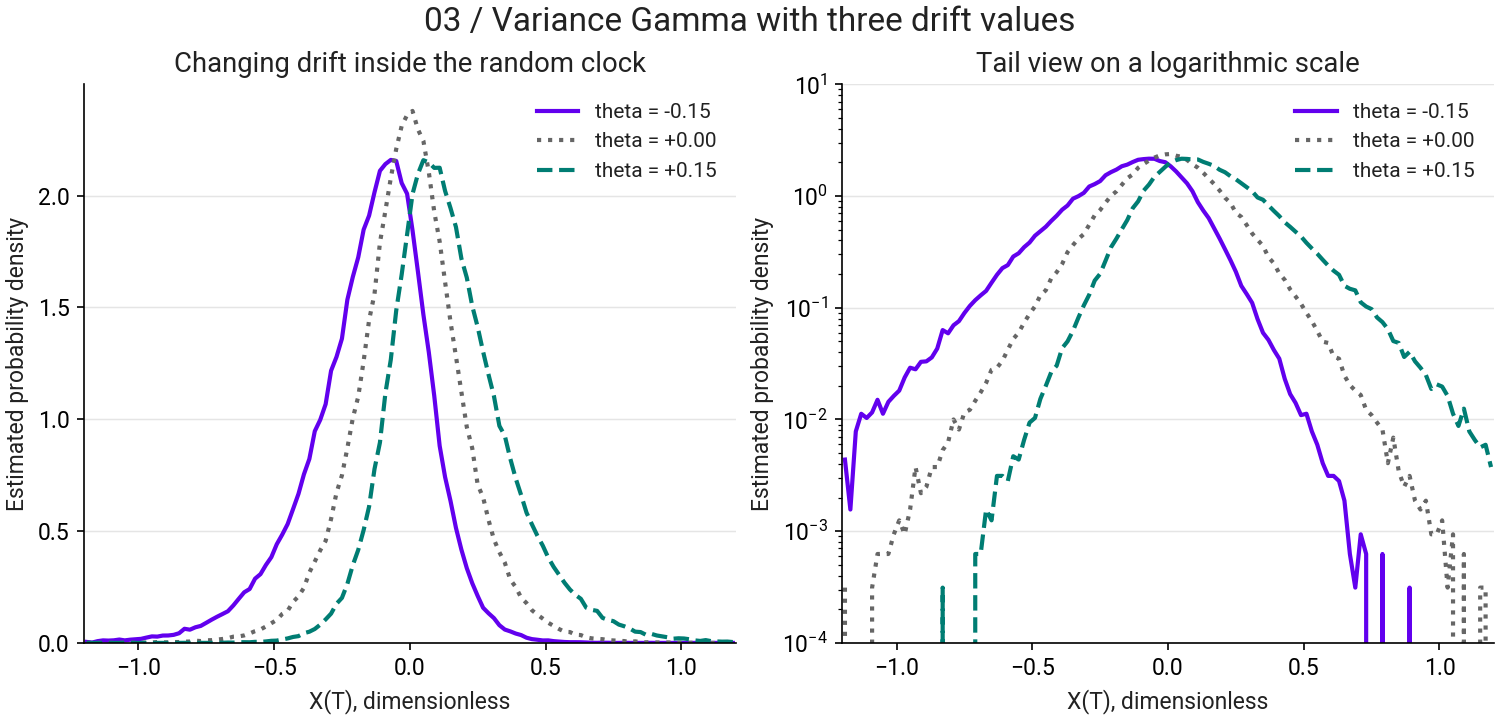

theta   mean(sim / theory)    variance(sim / theory)   outside plot
-0.15   -0.1497 / -0.1500      0.0486 / 0.0490       101/160000
+0.00   -0.0003 / +0.0000      0.0396 / 0.0400       4/160000
+0.15   +0.1490 / +0.1500      0.0485 / 0.0490       97/160000
Hypothetical samples: seed=2026092003; n=160,000 per theta; T=1.0; nu=0.4; sigma=0.2


In [4]:
# X(T) = theta*G + sigma*sqrt(G)*Z, G~Gamma(T/nu,nu), Z~N(0,1).
# Shared G and Z isolate changes in theta; there is no calibration or option pricing.
seed, n, T, nu, sigma = 2026092003, 160000, 1.0, 0.4, 0.2
rng = np.random.default_rng(seed)
g = rng.gamma(shape=T/nu, scale=nu, size=n)
z = rng.standard_normal(n)
bins = np.linspace(-1.2, 1.2, 121)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), layout="constrained")
print("theta   mean(sim / theory)    variance(sim / theory)   outside plot")
for theta, color, line in [(-0.15, PURPLE, "-"), (0.0, GRAY, ":"), (0.15, TEAL, "--")]:
    x = theta*g + sigma*np.sqrt(g)*z
    mean, variance = theta*T, (sigma*sigma + theta*theta*nu)*T
    # Sampling tolerances check the sampler, not model validity for market data.
    assert abs(x.mean()-mean) < 6*math.sqrt(variance/n)
    fourth = 3*variance**2 + (3*sigma**4*nu + 12*sigma*sigma*theta*theta*nu*nu + 6*theta**4*nu**3)*T
    assert abs(x.var()-variance) < 6*math.sqrt((fourth-variance**2)/n)
    counts, _ = np.histogram(x, bins=bins)
    density = counts / (n*np.diff(bins))  # Do not renormalize the visible range.
    centers = (bins[:-1]+bins[1:])/2
    for ax in axes:
        ax.plot(centers, density, color=color, linestyle=line, linewidth=2, label=f"theta = {theta:+.2f}")
    outside = np.count_nonzero((x<bins[0]) | (x>bins[-1]))
    print(f"{theta:+.2f}   {x.mean():+.4f} / {mean:+.4f}      {x.var():.4f} / {variance:.4f}       {outside}/{n}")
for ax in axes:
    ax.set(xlabel="X(T), dimensionless", ylabel="Estimated probability density", xlim=(-1.2, 1.2))
axes[0].set_title("Changing drift inside the random clock")
axes[0].set_ylim(bottom=0)
axes[1].set(title="Tail view on a logarithmic scale", yscale="log", ylim=(0.0001, 10))
fig.suptitle("03 / Variance Gamma with three drift values", fontsize=16)
finish(axes)
print(f"Hypothetical samples: seed={seed}; n={n:,} per theta; T={T}; nu={nu}; sigma={sigma}")
